# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 04: Transformações dos Dados (Pré-processamento)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                              | Local           |
|-------------------------------|---------------|-----------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_04_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='cyan'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q</font>

O dataset pertence ao domínio de aplicação de e-commerce e comportamento do consumidor online, tendo como objetivo principal possibilitar a previsão da intenção de compra dos usuários durante uma sessão de navegação em sites de compras virtuais; para isso, reúne informações de 12.330 sessões coletadas ao longo de um ano, contendo atributos numéricos e categóricos como número e duração de páginas visitadas (administrativas, informativas e de produtos), métricas de análise de tráfego (Bounce Rate, Exit Rate, Page Value), indicadores de datas especiais, dados técnicos (sistema operacional, navegador, região, tipo de tráfego), perfil do visitante (novo ou recorrente, fim de semana, mês) e, por fim, a variável alvo 'Revenue', que indica se a sessão resultou ou não em compra.

## <font color='green'>Preparação</font>

In [2]:
!pip install pandas scikit-learn ucimlrepo

In [3]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=468)

_X_uci = ds.data.features
_y_uci = ds.data.targets

df = pd.concat([_X_uci, _y_uci], axis='columns')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='cyan'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Ao dividir o dataset em treino e teste, podemos validar o comportamento do modelo. Assim, o modelo faz um treinamento com os dados disponíveis, depois apresentamos os dados de teste desconhecidos para poder generalizar bem os dados novos e colocar o modelo à prova.

### <font color='cyan'>Q2: Utilizando a função `train_test_split` biblioteca `scikit-learn`, divida as variáveis independentes (`X`) e a variável alvo (`y`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('Revenue', axis=1) #columns
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='cyan'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_train`).</font>

In [5]:
X_train

X_train['Month']

X_train['VisitorType']

X_train['Weekend']

,Weekend
1785,False
10407,False
286,False
6520,False
12251,True
...,...
11964,False
5191,True
5390,False
860,False


### <font color='cyan'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras originais.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [6]:
X_train['VisitorType'].sample(10, random_state=42)

,VisitorType
5258,Returning_Visitor
8368,Other
5564,Returning_Visitor
10481,Returning_Visitor
4570,Returning_Visitor
4815,Returning_Visitor
8558,Returning_Visitor
5247,Returning_Visitor
7681,Returning_Visitor
10353,New_Visitor


### <font color='cyan'>Q5: Aplique a técnica de `One-Hot Encoding` na variável escolhida utilizando a biblioteca scikit-learn.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='cyan'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_encoder = encoder.fit_transform(X_train[['VisitorType']])
X_test_encoder = encoder.transform(X_test[['VisitorType']])

### <font color='cyan'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='cyan'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [8]:
encoded_col = encoder.get_feature_names_out(['VisitorType'])
X_train_encoder_df = pd.DataFrame(X_train_encoder, columns=encoded_col, index=X_train.index) # np -> df
X_train_encoder_df.sample(10, random_state=42)

,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
5258,0.0,0.0,1.0
8368,0.0,1.0,0.0
5564,0.0,0.0,1.0
10481,0.0,0.0,1.0
4570,0.0,0.0,1.0
4815,0.0,0.0,1.0
8558,0.0,0.0,1.0
5247,0.0,0.0,1.0
7681,0.0,0.0,1.0
10353,1.0,0.0,0.0


Após aplicar a técnica, a variável categórica foi dividida entre todas as categorias e aplicado true (1) e false (2) na coluna correspondendo ao dado.

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='cyan'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Pois os escalonamento iguala a influência dos atributos no modelo.

### <font color='cyan'>Q8: Selecione uma coluna numérica contínua de `X_train`. Escreva o nome da característica selecionada abaixo.</font>

In [9]:
X_train['Administrative_Duration']

,Administrative_Duration
1785,0.000000
10407,14.000000
286,0.000000
6520,49.200000
12251,0.000000
...,...
11964,1005.608333
5191,0.000000
5390,0.000000
860,0.000000


### <font color='cyan'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [10]:
media_adm_duration = X_train['Administrative_Duration'].mean()
mediana_adm_duration = X_train['Administrative_Duration'].median()
desvio_padrao_adm_duration = X_train['Administrative_Duration'].std()
minimo_adm_duration = X_train['Administrative_Duration'].min()
maximo_adm_duration = X_train['Administrative_Duration'].max()

print("Média:", media_adm_duration)
print("Mediana:", mediana_adm_duration)
print("Desvio padrão:", desvio_padrao_adm_duration)
print("Mínimo:", minimo_adm_duration)
print("Máximo:", maximo_adm_duration)

Média: 81.10722578119547
Mediana: 8.0
Desvio padrão: 177.51105409510777
Mínimo: 0.0
Máximo: 3398.75


### <font color='cyan'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

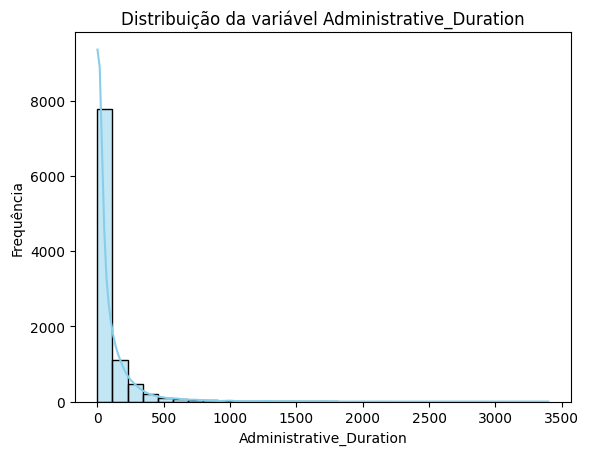

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(X_train['Administrative_Duration'], bins=30, kde=True, color='skyblue') # histograma com kernel

plt.title("Distribuição da variável Administrative_Duration")
plt.xlabel("Administrative_Duration")
plt.ylabel("Frequência")
plt.show()


### <font color='cyan'>Q11: Aplique o Escalonamento nesta variável. Você pode escolher entre a Padronização (`StandardScaler`) ou a Normalização (`MinMaxScaler`), ambas da biblioteca scikit-learn.</font>

- #### <font color='cyan'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_train` e `X_test`) pelos valores escalonados.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train['Administrative_Duration'] = scaler.fit_transform(X_train[['Administrative_Duration']])

X_test['Administrative_Duration'] = scaler.transform(X_test[['Administrative_Duration']])

### <font color='cyan'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [13]:
media_adm_duration = X_train['Administrative_Duration'].mean()
mediana_adm_duration = X_train['Administrative_Duration'].median()
desvio_padrao_adm_duration = X_train['Administrative_Duration'].std()
minimo_adm_duration = X_train['Administrative_Duration'].min()
maximo_adm_duration = X_train['Administrative_Duration'].max()

print("Média:", media_adm_duration)
print("Mediana:", mediana_adm_duration)
print("Desvio padrão:", desvio_padrao_adm_duration)
print("Mínimo:", minimo_adm_duration)
print("Máximo:", maximo_adm_duration)

Média: 0.023863839876776892
Mediana: 0.0023538065465244576
Desvio padrão: 0.05222833515119016
Mínimo: 0.0
Máximo: 1.0


### <font color='cyan'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

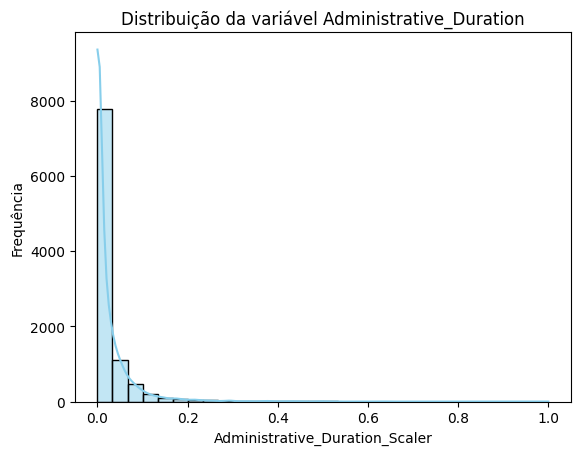

In [14]:
sns.histplot(X_train['Administrative_Duration'], bins=30, kde=True, color='skyblue') # histograma com kernel

plt.title("Distribuição da variável Administrative_Duration")
plt.xlabel("Administrative_Duration_Scaler")
plt.ylabel("Frequência")
plt.show()

### <font color='cyan'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='cyan'>O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='cyan'>O que aconteceu com a escala do eixo X e com o formato da curva no gráfico?</font>

Com o MinMaxScaler o mínimo foi fixado em 0 e o máximo em 1, mas a média e o desvio padrão ficam livresdependendo da distribuição original dos dados.

A escala do eixo X mudou para valores entre 0 e 1, visto que usei o MinMaxScaler mas o formato da curva não mudou pois ele não altera a forma da distribuição, apenas reescala os valores.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='cyan'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='cyan'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [15]:
df['Total_Abandon'] = df['BounceRates'] + df['ExitRates']
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Total_Abandon
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,0.40
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,0.10
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,0.40
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,0.19
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,0.07


### <font color='cyan'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [16]:
X = df.drop('Revenue', axis=1) #columns
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train['Total_Abandon'].sample(10, random_state=42)

,Total_Abandon
5258,0.150000
8368,0.005882
5564,0.046964
10481,0.019377
4570,0.011111
4815,0.055556
8558,0.110884
5247,0.004000
7681,0.015238
10353,0.120000


### <font color='cyan'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_train`).</font>
- #### <font color='cyan'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='cyan'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='cyan'>Importante: Utilize o `LabelEncoder` da biblioteca `scikit-learn` para transformar a variável alvo (`y_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)

corr_total_abandon_y_train = X_train['Total_Abandon'].corr(pd.Series(y_train_encoded))

print(corr_total_abandon_y_train)

0.01005404945445047


A correlação foi positiva, porém muito fraca. Mesmo uma correlação fraca não significa que a variável seja inútil — ela pode ainda agregar valor ao modelo quando combinada com outras.

## <font color='green'>**3.5 Extração / Seleção de Atributos**</font>

### <font color='cyan'>Q18: Qual a principal diferença conceitual entre Extração de Atributos (ex: `Principal Component Analysis`) e Seleção de Atributos (ex: `Variance Threshold`)? Explique.</font>

A diferença conceitual entre Extração de Atributos e Seleção de Atributos está no tipo de transformação que cada técnica realiza sobre os dados. Na Extração são criados atributos novos a partir dos existentes, ja na Seleção os atributos existentes são filtrados.

### <font color='cyan'>Q19: Aplique a técnica de Análise de Componentes Principais (PCA) em todas as variáveis numéricas escalonadas.</font>

- #### <font color='cyan'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis) e ajuste-o aos dados de treinamento.</font>
- #### <font color='cyan'>b) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='cyan'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='cyan'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='cyan'>c) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

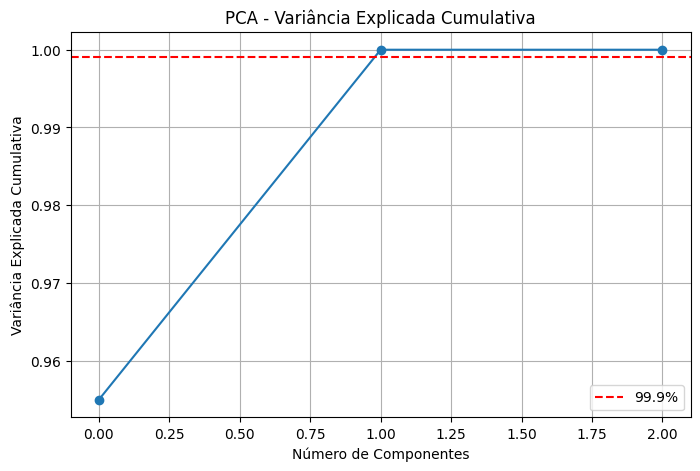

In [19]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train_encoder)

explained_variance_ratio_cumsum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(explained_variance_ratio_cumsum, marker='o')
plt.axhline(y=0.999, color='r', linestyle='--', label='99.9%')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Cumulativa')
plt.title('PCA - Variância Explicada Cumulativa')
plt.legend()
plt.grid(True)
plt.show()

 1 componente principal já atinge 99,9% da variância explicada, e o limiar foi escolhido para garantir máxima fidelidade dos dados após a transformação.

### <font color='cyan'>Q20: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='cyan'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='cyan'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='cyan'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='cyan'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [23]:
pca_final = PCA(n_components=1)

X_train_pca = pca_final.fit_transform(X_train_encoder)
X_test_pca = pca_final.transform(X_test_encoder)

print("Shape original treino:", X_train_encoder.shape)
print("Shape após PCA treino:", X_train_pca.shape)

print("Shape original teste:", X_test_encoder.shape)
print("Shape após PCA teste:", X_test_pca.shape)

pc1 = pca_final.components_[0]
abs_pc1 = np.abs(pc1)
indices_maiores_valores = np
indices_maiores_valores = np.argsort(abs_pc1)[-3:]
print(indices_maiores_valores)
for i in indices_maiores_valores:
    print(X_train_encoder_df.columns[i], pc1[i])

Shape original treino: (9864, 3)
Shape após PCA treino: (9864, 1)
Shape original teste: (2466, 3)
Shape após PCA teste: (2466, 1)
[1 0 2]
VisitorType_Other -0.01703792433520135
VisitorType_New_Visitor -0.6984338522767306
VisitorType_Returning_Visitor 0.715471776611932
